Знакомство с алгоритмом градиентного спуска

In [346]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pnd
# Оценка качества
from sklearn.metrics import accuracy_score, confusion_matrix

In [347]:
def std_deviation(data):
    N = len(data)
    data_mean = np.sum(data)/N
    return np.sqrt(np.sum((data-data_mean)**2)/N)


def Z_estimation(data):
    """Расчет Z-оценок для всех столбцов массива"""
    z_scores = np.zeros_like(data, dtype=float)
    for col in range(data.shape[1]):
        column_data = data[:, col]
        col_mean = np.sum(column_data) / len(column_data)
        std = std_deviation(column_data)
        if std == 0:
            z_scores[:, col] = 0
        else:
            z_scores[:, col] = (column_data - col_mean) / std
    return z_scores



def plot_regression(X_train, Y_train, X_test, Y_test, X_outliers, Y_outliers, 
                    w):
    """
    Визуализация данных и линий регрессии
    
    Параметры:
    X_train, Y_train - обучающая выборка
    X_test, Y_test - тестовая выборка
    X_outliers, Y_outliers - выбросы

    """
    # Основной график
    plt.figure(figsize=(14, 6))
    
    # 1. Обучающая выборка - синие точки
    plt.scatter(X_train[:, 1], Y_train, c='blue', s=30, alpha=0.6, 
                label='Обучающая выборка', zorder=2)
    
    # 2. Выбросы - красные, укрупненные
    if len(X_outliers) > 0:
        plt.scatter(X_outliers, Y_outliers, c='red', s=100, alpha=0.8, 
                    label='Выбросы (|Z| > 3)', edgecolors='darkred', zorder=3)
    
    # 3. Тестовая выборка - зеленые, укрупненные
    plt.scatter(X_test[:, 1], Y_test, c='green', s=80, alpha=0.8, 
                label='Тестовая выборка', edgecolors='darkgreen', zorder=4)

    
    # Веса после обучения
    w0 = w[0]  # bias (свободный член, B)
    w1 = w[1]  # коэффициент при x (K)

    # 1. Создаём значения x для линии (от мин до макс)
    x_line = np.linspace(X_train[:, 1].min(), X_train[:, 1].max(), 200)

    # 2. Вычисляем y для линии регрессии
    # Формула: y = w0 + w1 * x
    y_line = w0 + w1 * x_line


    # Линия регрессии
    plt.plot(x_line, y_line, 'r-', linewidth=2, 
            label=f'Регрессия: y = {w1:.3f}x + {w0:.3f}', zorder=5)

    # Настройка графика
    plt.xlabel('X', fontsize=12)
    plt.ylabel('Y', fontsize=12)
    plt.title('Линейная регрессия (градиентный спуск)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    


In [348]:
# Загрузка данных
data = np.load("C:/Users/Kirill/Desktop/magsitr/sem 2/ML/pr4/ml1var1.npy")
data

array([[ 0.        ,  4.10839447],
       [ 0.2       ,  4.00671229],
       [ 0.4       ,  4.48055749],
       [ 0.6       ,  4.07821949],
       [ 0.8       ,  4.17400515],
       [ 1.        ,  3.72974505],
       [ 1.2       ,  4.23470147],
       [ 1.4       , -5.        ],
       [ 1.6       ,  4.26411087],
       [ 1.8       ,  5.07986573],
       [ 2.        ,  5.15322088],
       [ 2.2       ,  5.32272655],
       [ 2.4       ,  5.77194395],
       [ 2.6       ,  5.29930011],
       [ 2.8       ,  5.97379016],
       [ 3.        ,  6.07973142],
       [ 3.2       ,  6.34970421],
       [ 3.4       ,  6.05398326],
       [ 3.6       ,  6.0349869 ],
       [ 3.8       ,  7.34518953],
       [ 4.        ,  6.33911781],
       [ 4.2       ,  7.29866291],
       [ 4.4       ,  6.19333837],
       [ 4.6       ,  6.93755118],
       [ 4.8       ,  6.55543807],
       [ 5.        ,  7.44284414],
       [ 5.2       ,  7.33206607],
       [ 5.4       ,  7.13722972],
       [ 5.6       ,

In [349]:
# Удаление выбросов
z_scores = Z_estimation(data)
mask = np.all(np.abs(z_scores) <= 3, axis=1)
data_clean = data[mask]
# Сохраняем выбросы для визуализации (Пункт 11)
X_outliers = data[~mask, 0]
Y_outliers = data[~mask, 1]
print(f"Всего точек: {len(data)}")
print(f"Осталось после очистки: {len(data_clean)}")
print(f"Удалено выбросов: {len(data) - len(data_clean)}")

X = data_clean[:, 0]
Y = data_clean[:, 1]


Всего точек: 36
Осталось после очистки: 34
Удалено выбросов: 2


In [350]:
# Разделение на выборки
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=0.25, 
    random_state=42
)

print(f"\nОбучающая выборка: {len(X_train)} точек")
print(f"Тестовая выборка: {len(X_test)} точек")
X


Обучающая выборка: 25 точек
Тестовая выборка: 9 точек


array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.6, 1.8, 2. , 2.2, 2.4, 2.6,
       2.8, 3. , 3.2, 3.4, 3.6, 3.8, 4. , 4.2, 4.4, 4.6, 4.8, 5. , 5.2,
       5.4, 5.6, 5.8, 6. , 6.2, 6.4, 6.6, 6.8])

![alt text](image.png)

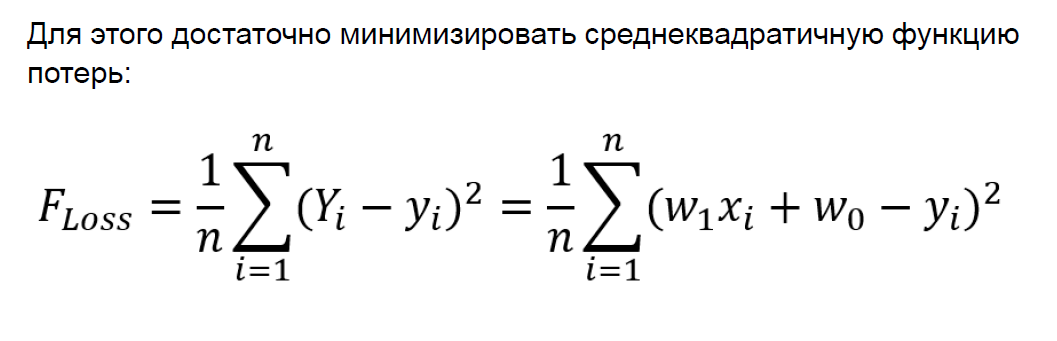

In [351]:
def F_loss(w, x, y):
    """
    Вычисляет среднеквадратичную ошибку (MSE)
    
    Параметры:
    w : ndarray формы (n_features,) или (n_features, 1)
        Вектор весов модели (включая bias, если он есть в X)
    X : ndarray формы (n_samples, n_features)
        Матрица признаков
    y : ndarray формы (n_samples,)
        Вектор истинных значений
    
    Возвращает:
    float : значение MSE
    """

    y_pred = x @ w # w1*x+w0
    return np.mean((y_pred - y) ** 2)

В случае двух коэффициентов формулы расчета будут выглядеть так 
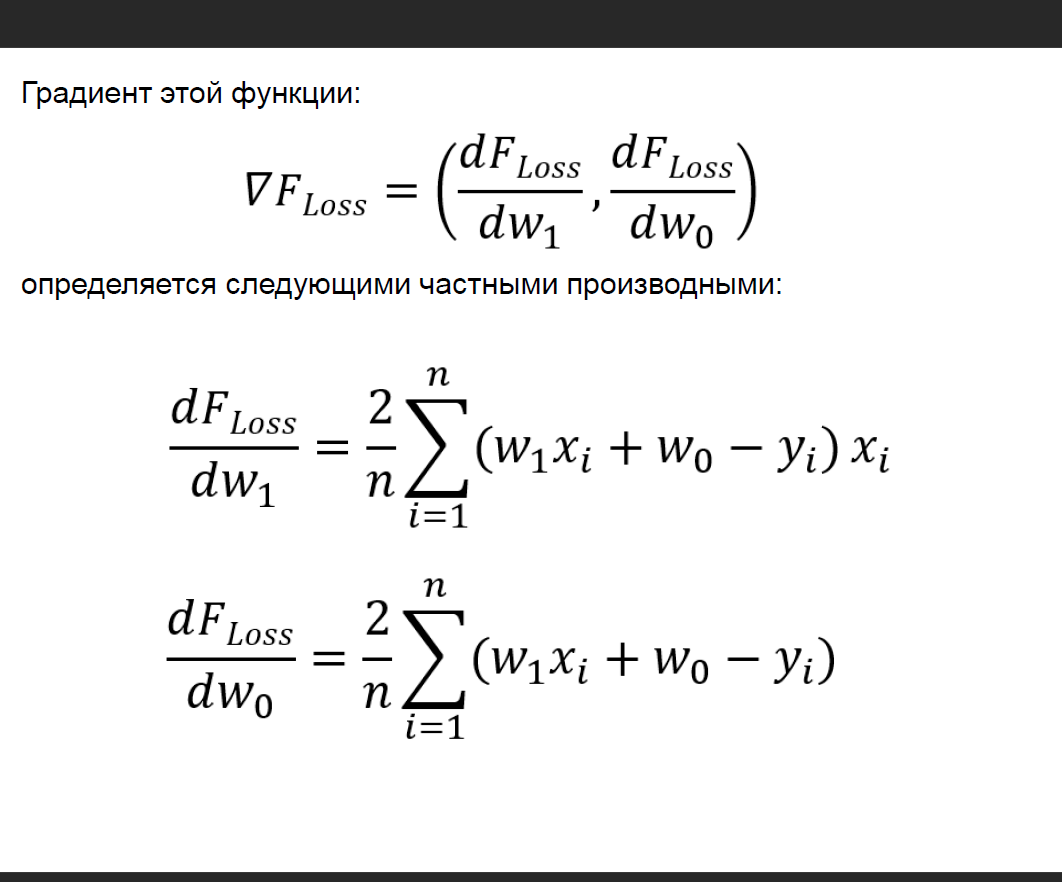

Не трудно заметить что для общего случая градиент будет расчесываться так (2/n) * X.T @ errors
Так как в матричном виде это выглядит так

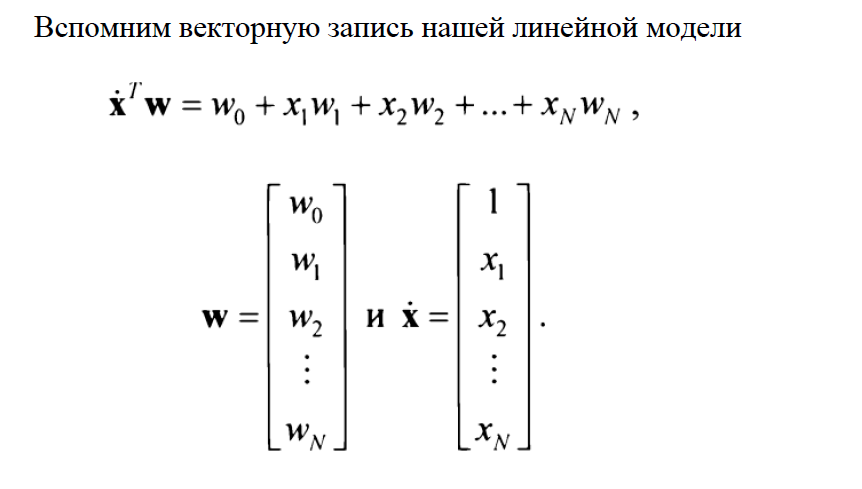

In [352]:
def compute_gradients(w, x, y):
    """
    Вычисляет градиенты для всех весов
    
    Параметры:
    w : ndarray формы (n_features,) или (n_features, 1)
        Вектор весов модели (включая bias, если он есть в X)
    X : ndarray формы (n_samples, n_features)
        Матрица признаков
    y : ndarray формы (n_samples,)
        Вектор истинных значений
    
    Возвращает:
    gradients : ndarray формы (n_features,)
    """

    y_pred = x @ w # w1*x+w0
    errors = y_pred - y
    return (2/len(y)) * (x.T @ errors)
    

In [353]:
# Добавляем bias (столбец единиц)
# Первый столбец - единицы (для bias w0)
X_train = np.column_stack([np.ones(len(X_train)), X_train])
lmb_min = 0.001
k = 10 # доп коэфициент для lambda
n = 0 # номер шага обучения
max_iterations = 1000
w = np.array([1,1]) # порядок записи такой w0, w1, w2, ..., wi



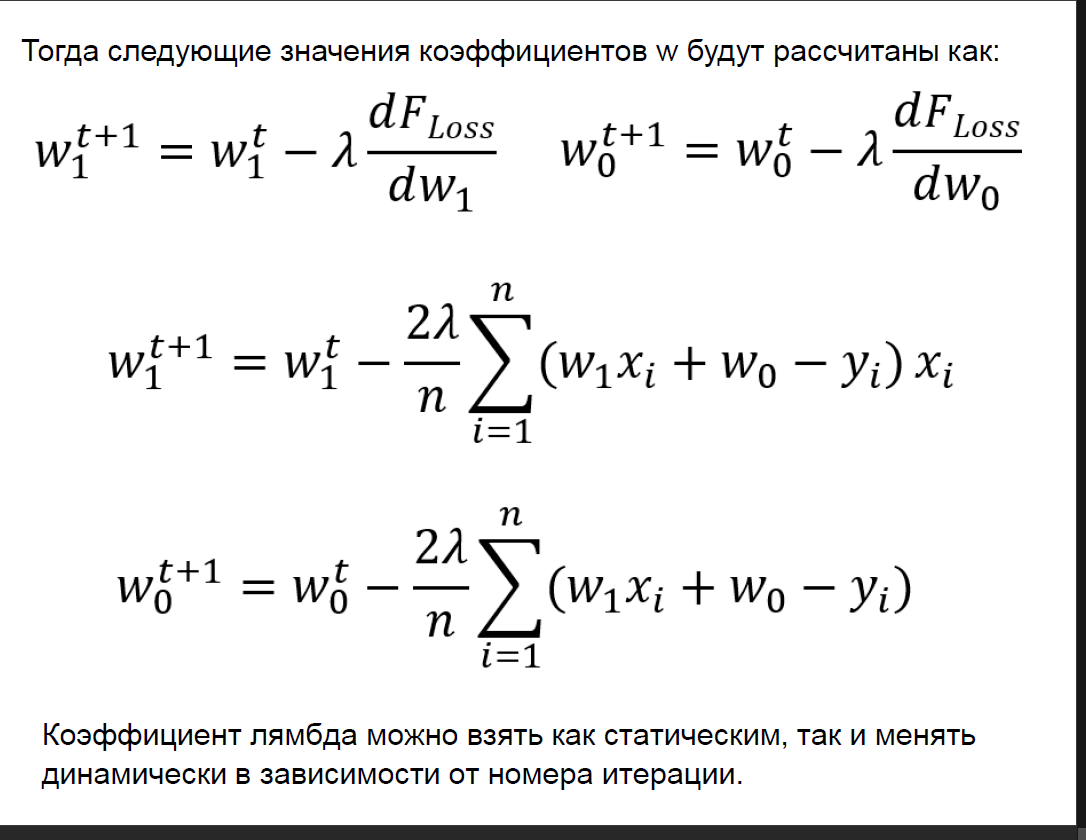

In [354]:
current_loss = F_loss(w, X_train, Y_train)
history = {'w0': [w[0]], 'w1': [w[1]], 'loss': [current_loss]}
while (current_loss > 1e-6) and n<max_iterations:
    n+=1
    lmb = max(1/(n+k),lmb_min)
    w =  w - lmb*compute_gradients(w, X_train, Y_train)
    current_loss = F_loss(w, X_train, Y_train)
    history['w0'].append(w[0])
    history['w1'].append(w[1])
    history['loss'].append(current_loss)
    if n % 50 == 0 or n < 20:
        print(f"Итерация {n}: loss = {current_loss}, веса = {w}")
    

print(f"\nОбучение завершено!")
print(f"Итоговые веса: {w}")
print(f"Итоговая ошибка: {F_loss(w, X_train, Y_train)}")
X_test = np.column_stack([np.ones(len(X_test)), X_test])
print(f"Ошибка на тестовых данных: {F_loss(w, X_test, Y_test)}")

Итерация 1: loss = 6.712189878579929, веса = [1.33174326 1.81186904]
Итерация 2: loss = 12.572643203173484, веса = [1.15296635 0.42876504]
Итерация 3: loss = 20.557131687606592, веса = [1.68784697 2.30954274]
Итерация 4: loss = 27.017527407482834, веса = [ 1.25907353 -0.06267758]
Итерация 5: loss = 27.836003650699286, веса = [1.91555027 2.46818507]
Итерация 6: loss = 22.364619803853056, веса = [1.44924688 0.01639045]
Итерация 7: loss = 14.104069876317697, веса = [1.97672303 2.04457149]
Итерация 8: loss = 7.197301401548063, веса = [1.70416958 0.52293266]
Итерация 9: loss = 3.2836692416781834, веса = [1.98079602 1.48339333]
Итерация 10: loss = 1.6846302818536987, веса = [1.91242292 0.92243385]
Итерация 11: loss = 1.1860552115987117, веса = [2.0226395  1.17970374]
Итерация 12: loss = 1.044307404775518, веса = [2.04391992 1.05611665]
Итерация 13: loss = 0.9857921744786188, веса = [2.09638421 1.08713466]
Итерация 14: loss = 0.9435560970897652, веса = [2.1341224  1.06574446]
Итерация 15: los

In [355]:

# Создаём сетку значений для w0 и w1
w0_range = np.linspace(w[0] - 50, w[0] + 50, 100)  # диапазон вокруг найденного w0
w1_range = np.linspace(w[1] - 50, w[1] + 50, 100)  # диапазон вокруг найденного w1
W0, W1 = np.meshgrid(w0_range, w1_range)

# Вычисляем функцию потерь для каждой пары (w0, w1)
Loss_surface = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        w_temp = np.array([W0[i, j], W1[i, j]])
        Loss_surface[i, j] = F_loss(w_temp, X_train, Y_train)

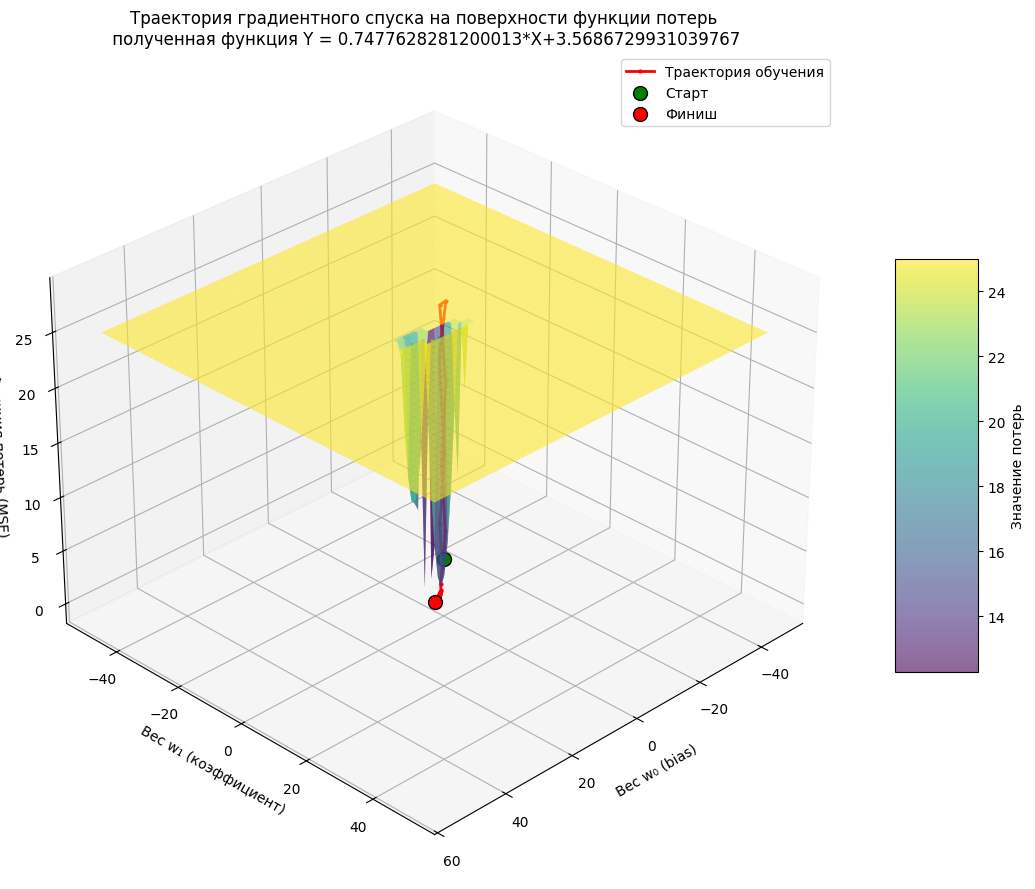

In [356]:
# Создаём фигуру и 3D-ось
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
Loss_surface = np.clip(Loss_surface, 0, 25)  # обрезать значения выше 5000
# Рисуем поверхность функции потерь
surf = ax.plot_surface(W0, W1, Loss_surface, 
                       cmap='viridis', alpha=0.6, edgecolor='none')

# Рисуем траекторию изменения весов (из истории обучения)
# Предположим, что history — это список словарей или словарь со списками
ax.plot(history['w0'], history['w1'], history['loss'], 
        color='red', linewidth=2, label='Траектория обучения', marker='o', markersize=2)

# Отмечаем начальную и конечную точки
ax.scatter(history['w0'][0], history['w1'][0], history['loss'][0], 
           color='green', s=100, label='Старт', edgecolors='black')
ax.scatter(history['w0'][-1], history['w1'][-1], history['loss'][-1], 
           color='red', s=100, label='Финиш', edgecolors='black')
# Подписи и оформление
ax.set_xlabel('Вес w₀ (bias)', fontsize=10)
ax.set_ylabel('Вес w₁ (коэффициент)', fontsize=10)
ax.set_zlabel('Функция потерь (MSE)', fontsize=10)
ax.set_title(f'Траектория градиентного спуска на поверхности функции потерь\n полученная функция Y = {w[1]}*X+{w[0]}', fontsize=12)
ax.legend()
ax.view_init(elev=30, azim=45)  # угол обзора
#ограничваем график по оси z

# Добавляем цветовую шкалу
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Значение потерь')

plt.tight_layout()
plt.show()

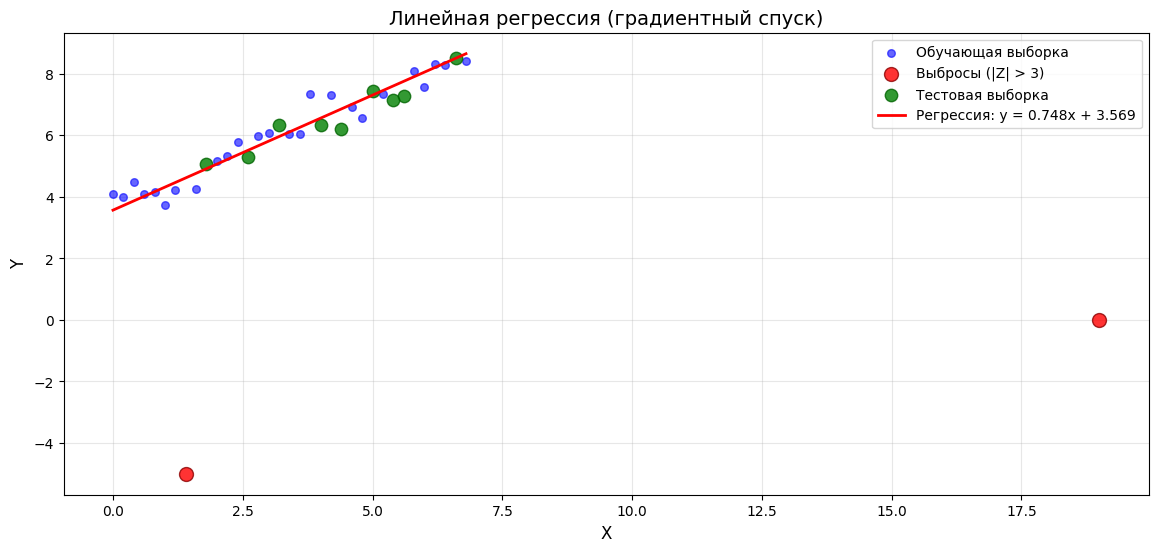

In [357]:
plot_regression(X_train, Y_train, X_test, Y_test, X_outliers, Y_outliers, w)

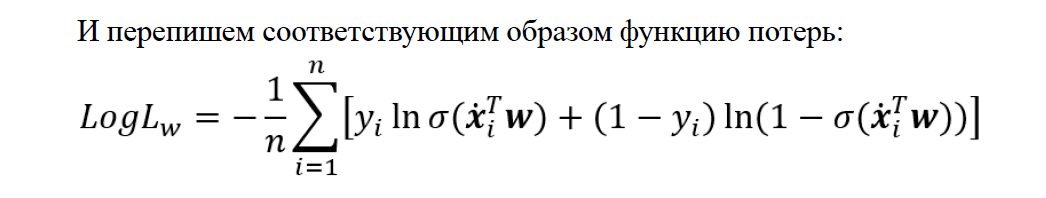

Построение модели бинарной классификации при помощи логистической регрессии

Формула градиента

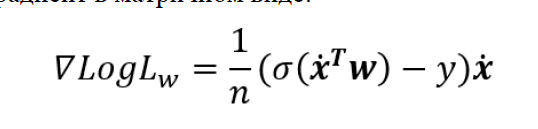

In [ ]:
def sigmoid(z):
    """Сигмоидная функция"""
    return 1 / (1 + np.exp(-z))

def loss_log(w, x, y):
    """
    Вычисляет логистическую функцию потерь (binary cross-entropy)
    
    Параметры:
    w : ndarray формы (n_features,) или (n_features, 1)
        Вектор весов модели (включая bias, если он есть в X)
    X : ndarray формы (n_samples, n_features)
        Матрица признаков
    y : ndarray формы (n_samples,)
        Вектор истинных значений
    
    Возвращает:
    float : значение MSE
    """

    z = x @ w # w1*x+w0

    # Добавляем epsilon для избежания log(0)
    epsilon = 1e-15
    sigma = sigmoid(z)
    sigma = np.clip(sigma, epsilon, 1 - epsilon)

    return -1/len(y)*np.sum(y*np.log(sigma)+(1-y)*np.log(1-sigma))
def compute_log_grad(w, x, y):
    """
    Вычисляет градиент логистической функции потерь
    """
    return 1/len(y) * x.T @ (sigmoid(x @ w) - y) 

def predict(w, X, threshold=0.5):
    """Предсказание классов"""
    proba = sigmoid(X @ w)
    return (proba >= threshold).astype(int)

def plot_bin_clasifer(x, X_test, Y_test , X_train, Y_train, w):
    """Отрисовка классов бинарной классификации"""
    
    plt.figure(figsize=(10, 6))
    x = x.to_numpy()  # Преобразуем DataFrame в NumPy


    plt.scatter(X_train[Y_train == 0, 1], X_train[Y_train == 0, 2], 
                c='blue', label='Класс 0 (train)', alpha=0.6, edgecolors='black', s=50)
    plt.scatter(X_train[Y_train == 1, 1], X_train[Y_train == 1, 2], 
                c='red', label='Класс 1 (train)', alpha=0.6, edgecolors='black', s=50)
    plt.scatter(X_test[Y_test == 0, 1], X_test[Y_test == 0, 2], 
                c='blue', marker='x', s=100, linewidths=2, label='Класс 0 (test)')
    plt.scatter(X_test[Y_test == 1, 1], X_test[Y_test == 1, 2], 
                c='red', marker='x', s=100, linewidths=2, label='Класс 1 (test)')


    plt.xlabel('x1', fontsize=12)
    plt.ylabel('x2', fontsize=12)
    plt.title('Decision Boundary (Логистическая регрессия)', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Чтение и разбиение данных

In [359]:
data1 = pnd.read_csv('task11.csv')
data2 = pnd.read_csv('task21.csv')
x = data1.drop(columns=['target'])
y = data1['target']
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, 
    test_size=0.25, 
    random_state=42
)
x

,x1,x2
0,9.249743,12.797165
1,26.118513,13.936663
2,8.696962,11.116652
3,21.614879,6.138127
4,11.247285,12.849175
...,...,...
395,24.402084,10.749480
396,9.384956,12.256265
397,25.091591,10.087860
398,12.844631,10.026040


In [360]:
# Добавляем bias (столбец единиц)
# Первый столбец - единицы (для bias w0)
X_train = np.column_stack([np.ones(len(X_train)), X_train])
X_test = np.column_stack([np.ones(len(X_test)), X_test])
lmb_min = 0.001
k = 10 # доп коэфициент для lambda
n = 0 # номер шага обучения
max_iterations = 1000
w = np.array([1,1,1]) # порядок записи такой w0, w1, w2, ..., wi


Обучение модели бинарной классификации при помощи логистической регрессии данные task11.csv

In [361]:
current_loss = loss_log(w, X_train, Y_train)
history = {'w0': [w[0]], 'w1': [w[1]], 'w2': [w[2]], 'loss': [current_loss]}
while (current_loss > 1e-7) and n<max_iterations:
    n+=1
    lmb = max(1/(n+k),lmb_min)
    w =  w - lmb*compute_log_grad(w, X_train, Y_train)
    current_loss = loss_log(w, X_train, Y_train)
    history['w0'].append(w[0])
    history['w1'].append(w[1])
    history['w2'].append(w[2])
    history['loss'].append(current_loss)
    print(f"Итерация {n}: loss = {current_loss}, веса = {w}")
    

print(f"\nОбучение завершено!")
print(f"Итоговые веса: {w}")
print(f"Итоговая ошибка: {loss_log(w, X_train, Y_train)}")

print(f"Ошибка на тестовых данных: {loss_log(w, X_test, Y_test)}")

Итерация 1: loss = 5.78438544797588, веса = [0.95636366 0.60763759 0.56554729]
Итерация 2: loss = 2.316300274574173, веса = [0.91636653 0.24798873 0.16731738]
Итерация 3: loss = 1.4376825317548099, веса = [ 0.87994017 -0.07995366 -0.19632382]
Итерация 4: loss = 3.072551758673026, веса = [0.90799486 0.52305769 0.07894944]
Итерация 5: loss = 0.5488636165774293, веса = [ 0.87612125  0.23614117 -0.23863892]
Итерация 6: loss = 0.9128233887830317, веса = [ 0.85849852  0.08888888 -0.40864827]
Итерация 7: loss = 1.62644157056223, веса = [ 0.87775869  0.50013502 -0.20500916]
Итерация 8: loss = 0.2872381368868405, веса = [ 0.85248359  0.27049747 -0.45715674]
Итерация 9: loss = 0.2835804716926372, веса = [ 0.85139306  0.31701838 -0.45156727]
Итерация 10: loss = 0.27589161543519825, веса = [ 0.8457173   0.28974635 -0.49554816]
Итерация 11: loss = 0.2702681507858417, веса = [ 0.84554221  0.34117598 -0.48175135]
Итерация 12: loss = 0.2578090358343522, веса = [ 0.84045131  0.31473123 -0.52092677]
Ите


=== Обучающая выборка ===
Accuracy: 0.9367
Confusion Matrix:
[[130  14]
 [  5 151]]

=== Тестовая выборка ===
Accuracy: 0.9700
Confusion Matrix:
[[54  2]
 [ 1 43]]


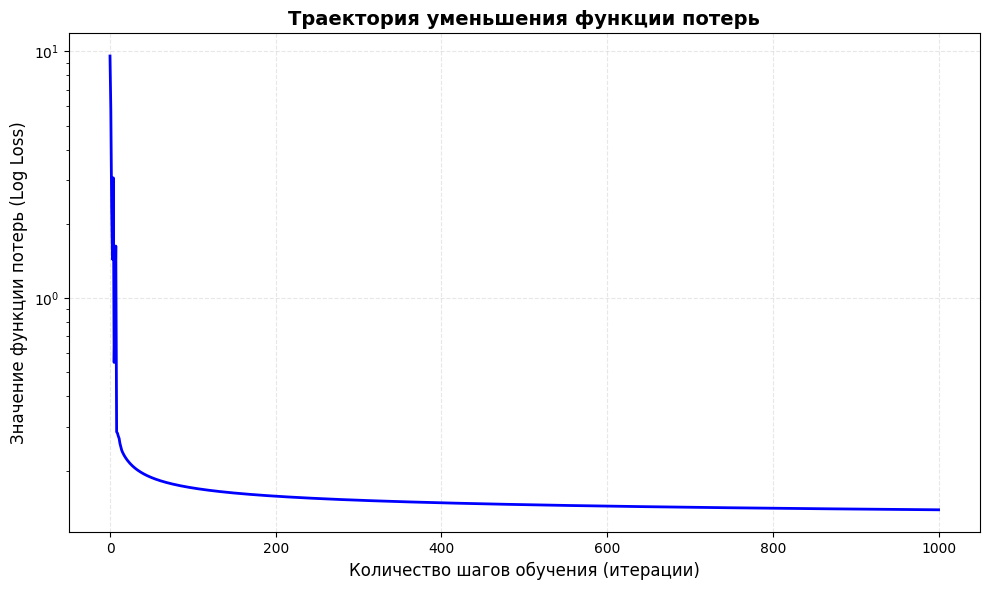

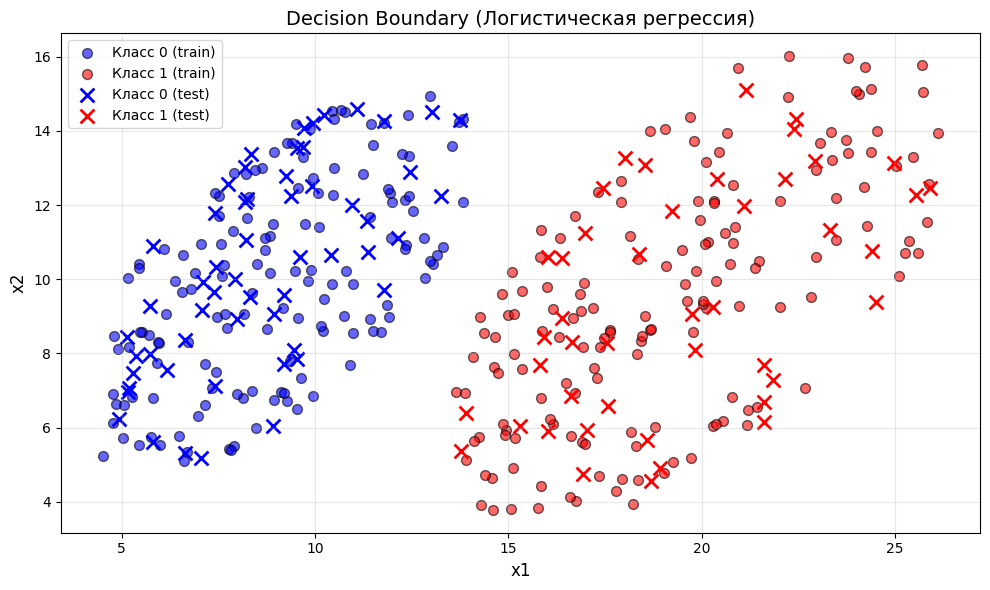

In [362]:

y_train_pred = predict(w, X_train)
y_test_pred = predict(w, X_test)

print("\n=== Обучающая выборка ===")
print(f"Accuracy: {accuracy_score(Y_train, y_train_pred):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(Y_train, y_train_pred)}")

print("\n=== Тестовая выборка ===")
print(f"Accuracy: {accuracy_score(Y_test, y_test_pred):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(Y_test, y_test_pred)}")

# Построение графика зависимости потерь от количества итераций
plt.figure(figsize=(10, 6))
plt.plot(range(len(history['loss'])), history['loss'], linewidth=2, color='blue')
plt.xlabel('Количество шагов обучения (итерации)', fontsize=12)
plt.ylabel('Значение функции потерь (Log Loss)', fontsize=12)
plt.title('Траектория уменьшения функции потерь', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.yscale('log')  # Логарифмическая шкала для лучшей визуализации убывания
plt.tight_layout()
plt.show()

plot_bin_clasifer(x, X_test, Y_test , X_train, Y_train, w)

In [363]:
x = data2.drop(columns=['target'])
y = data2['target']
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, 
    test_size=0.25, 
    random_state=42
)

Обучение модели бинарной классификации при помощи логистической регрессии данные task21.csv

In [364]:
# Добавляем bias (столбец единиц)
# Первый столбец - единицы (для bias w0)
X_train = np.column_stack([np.ones(len(X_train)), X_train])
lmb_min = 0.001
k = 10 # доп коэфициент для lambda
n = 0 # номер шага обучения
max_iterations = 1000
w = np.array([1,1,1]) # порядок записи такой w0, w1, w2, ..., wi

current_loss = loss_log(w, X_train, Y_train)
history = {'w0': [w[0]], 'w1': [w[1]], 'w2': [w[2]], 'loss': [current_loss]}
while (current_loss > 1e-7) and n<max_iterations:
    n+=1
    lmb = max(1/(n+k),lmb_min)
    w =  w - lmb*compute_log_grad(w, X_train, Y_train)
    current_loss = loss_log(w, X_train, Y_train)
    history['w0'].append(w[0])
    history['w1'].append(w[1])
    history['w2'].append(w[2])
    history['loss'].append(current_loss)
    print(f"Итерация {n}: loss = {current_loss}, веса = {w}")

Итерация 1: loss = 4.5996698620640935, веса = [0.95636365 0.78755475 0.29771492]
Итерация 2: loss = 0.40000339626473913, веса = [ 0.91638791  0.59290749 -0.34577854]
Итерация 3: loss = 0.4025361193549305, веса = [ 0.92262936  0.61087555 -0.30832076]
Итерация 4: loss = 0.40510949592568113, веса = [ 0.92225701  0.59487279 -0.35618181]
Итерация 5: loss = 0.4028942991254379, веса = [ 0.92873317  0.61615884 -0.30963676]
Итерация 6: loss = 0.4009285726955938, веса = [ 0.92825718  0.60128906 -0.35337249]
Итерация 7: loss = 0.3970098223778201, веса = [ 0.93334525  0.61657263 -0.32025203]
Итерация 8: loss = 0.3950641085697713, веса = [ 0.93403334  0.60904498 -0.34375626]
Итерация 9: loss = 0.3939039141867909, веса = [ 0.93732367  0.61584465 -0.33055578]
Итерация 10: loss = 0.3934814743057288, веса = [ 0.93893468  0.61422589 -0.33817811]
Итерация 11: loss = 0.3932908322040145, веса = [ 0.94119943  0.61653668 -0.33560828]
Итерация 12: loss = 0.3931692156049459, веса = [ 0.94304744  0.61706182 -0.

In [365]:
print(f"\nОбучение завершено!")
print(f"Итоговые веса: {w}")
print(f"Итоговая ошибка: {loss_log(w, X_train, Y_train)}")
X_test = np.column_stack([np.ones(len(X_test)), X_test])
print(f"Ошибка на тестовых данных: {loss_log(w, X_test, Y_test)}")


Обучение завершено!
Итоговые веса: [ 1.100834    0.65162082 -0.36248245]
Итоговая ошибка: 0.3860148748960964
Ошибка на тестовых данных: 0.3600360705603095



=== Обучающая выборка ===
Accuracy: 0.7967
Confusion Matrix:
[[119  25]
 [ 36 120]]

=== Тестовая выборка ===
Accuracy: 0.8400
Confusion Matrix:
[[51  5]
 [11 33]]


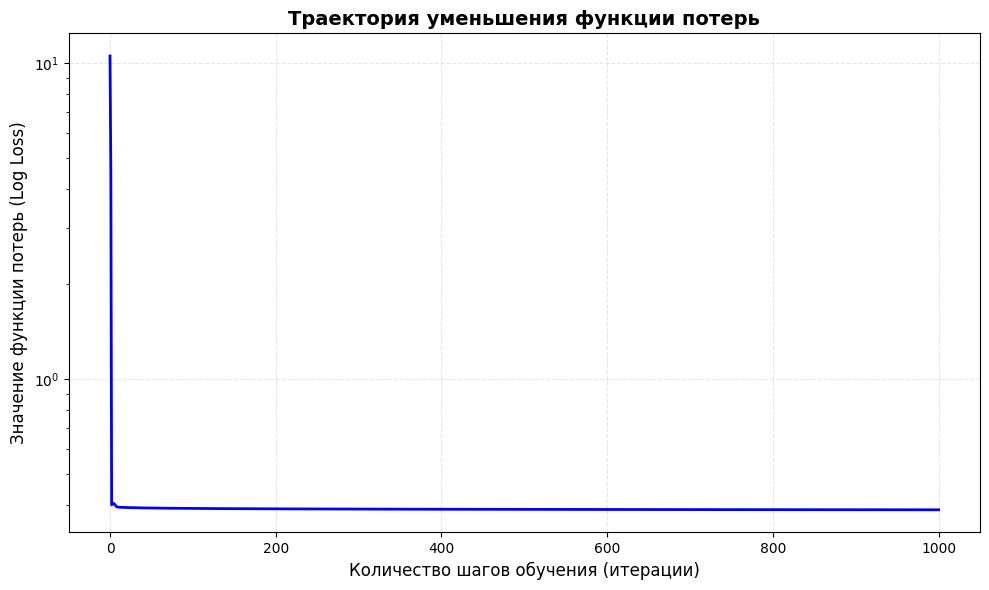

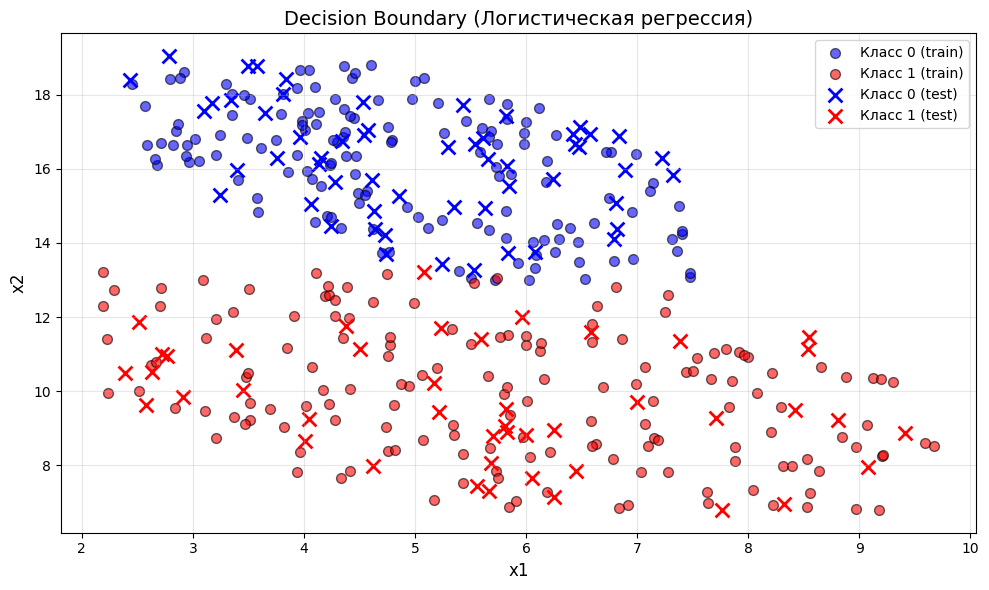

In [366]:

y_train_pred = predict(w, X_train)
y_test_pred = predict(w, X_test)

print("\n=== Обучающая выборка ===")
print(f"Accuracy: {accuracy_score(Y_train, y_train_pred):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(Y_train, y_train_pred)}")

print("\n=== Тестовая выборка ===")
print(f"Accuracy: {accuracy_score(Y_test, y_test_pred):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(Y_test, y_test_pred)}")

# Построение графика зависимости потерь от количества итераций
plt.figure(figsize=(10, 6))
plt.plot(range(len(history['loss'])), history['loss'], linewidth=2, color='blue')
plt.xlabel('Количество шагов обучения (итерации)', fontsize=12)
plt.ylabel('Значение функции потерь (Log Loss)', fontsize=12)
plt.title('Траектория уменьшения функции потерь', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.yscale('log')  # Логарифмическая шкала для лучшей визуализации убывания
plt.tight_layout()
plt.show()

plot_bin_clasifer(x, X_test, Y_test , X_train, Y_train, w)